In [62]:
class CountReason:
    def __init__(self, p_c, p_l, p_lc):
        self.p_c = p_c
        self.p_l = p_l
        self.p_lc = p_lc
        self.p_cl = None

    def count_reason(self):
        self.p_cl = (self.p_lc * self.p_c) / self.p_l

### Przypadek #1:

Wysokie prawdopodobieństwo utraty węchu, pod warunkiem zachorowania na COVID

In [63]:
p_c = 0.0062
p_l = 0.01
p_lc = 0.9

covid = CountReason(p_c, p_l, p_lc)
covid.count_reason()
print(f"Prawdopodobieństwo zachorowania na COVID pod warunkiem utraty węchu:\n{covid.p_cl * 100:.2f}%")

Prawdopodobieństwo zachorowania na COVID pod warunkiem utraty węchu:
55.80%


### Przypadek #2:

Utrata węchu jest bardziej popularnym zjawiskiem

In [64]:
p_c = 0.0062
p_l = 0.1
p_lc = 0.9

covid = CountReason(p_c, p_l, p_lc)
covid.count_reason()
print(f"Prawdopodobieństwo zachorowania na COVID pod warunkiem utraty węchu:\n{covid.p_cl * 100:.2f}%")

Prawdopodobieństwo zachorowania na COVID pod warunkiem utraty węchu:
5.58%


### Przypadek #3:

Mniejsze prawdodobieństwo występowania utraty węchu podczas zakarzenia COVIDem

In [65]:
p_c = 0.0062
p_l = 0.01
p_lc = 0.1

covid = CountReason(p_c, p_l, p_lc)
covid.count_reason()
print(f"Prawdopodobieństwo zachorowania na COVID pod warunkiem utraty węchu:\n{covid.p_cl * 100:.2f}%")

Prawdopodobieństwo zachorowania na COVID pod warunkiem utraty węchu:
6.20%


### Przypadek #4:

Obliczanie na podstawie BRAKU utraty węchu (czyli szansa na zachorowanie bez objawów).

In [66]:
p_c = 0.0062
p_l = 0.01
p_not_l = 1 - p_l
p_lc = 0.9
p_not_lc = 1 - p_lc

covid = CountReason(p_c, p_not_l, p_not_lc)
covid.count_reason()
print(f"Prawdopodobieństwo zachorowania na COVID pod warunkiem braku utraty węchu:\n{covid.p_cl * 100:.2f}%")

Prawdopodobieństwo zachorowania na COVID pod warunkiem braku utraty węchu:
0.06%


### Różne przypadki z losowymi wartościami parametrów

In [67]:
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import matplotlib.pyplot as plt

params = [
    (0.011375, 0.1, 0.9), #procent szans w 2021
    (0.02, 0.5, 0.75),
    (0.01, 0.2, 0.75),
    (0.0001, 0.1, 0.1) # procent szans w 2025
]
p_c_values = [p[0] for p in params]
p_l_values = [p[1] for p in params]
p_lc_values = [p[2] for p in params]

p_cl_results = []
for i in params:
    print(f"P(C) = {i[0]}, P(L) = {i[1]}, P(L|C) = {i[2]}")

    covid = CountReason(i[0], i[1], i[2])
    covid.count_reason()
    print(f"Prawdopodobieństwo zachorowania na COVID pod warunkiem utraty węchu: {covid.p_cl * 100:.2f}%")
    p_cl_results.append(covid.p_cl)


P(C) = 0.011375, P(L) = 0.1, P(L|C) = 0.9
Prawdopodobieństwo zachorowania na COVID pod warunkiem utraty węchu: 10.24%
P(C) = 0.02, P(L) = 0.5, P(L|C) = 0.75
Prawdopodobieństwo zachorowania na COVID pod warunkiem utraty węchu: 3.00%
P(C) = 0.01, P(L) = 0.2, P(L|C) = 0.75
Prawdopodobieństwo zachorowania na COVID pod warunkiem utraty węchu: 3.75%
P(C) = 0.0001, P(L) = 0.1, P(L|C) = 0.1
Prawdopodobieństwo zachorowania na COVID pod warunkiem utraty węchu: 0.01%


### Różne przypadki utraty węchu pod warunkiem COVIDa przy różnych *P(L) i P(L|C)* przy prawdopodobieństwie COVIDa w populacji **P(C) = 0.0062**

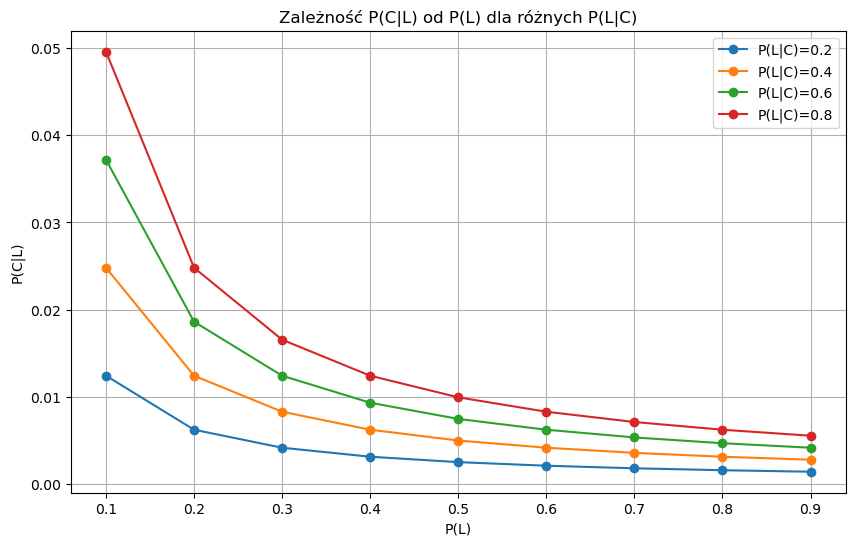

In [68]:
p_c = 0.0062
p_lc = np.arange(0.2, 1, 0.2)
p_l = np.arange(0.1, 1, 0.1)
p_cl = []

for i in p_l:
    covid = CountReason(p_c, i, p_lc)
    covid.count_reason()
    p_cl.append(covid.p_cl)

plt.figure(figsize=(10, 6))
for p_lc_val in p_lc:
    p_cl = []
    for i in p_l:
        covid = CountReason(p_c, i, p_lc_val)
        covid.count_reason()
        p_cl.append(covid.p_cl)
    plt.plot(p_l, p_cl, marker='o', label=f'P(L|C)={p_lc_val:.1f}')

plt.xlabel('P(L)')
plt.ylabel('P(C|L)')
plt.title('Zależność P(C|L) od P(L) dla różnych P(L|C)')
plt.legend()
plt.grid(True)
plt.show()


### Przypadek #5:

Spora szansa na zachorowanie na COVID, bardzo małe szanse utraty węchu, rzadka utrata węchu pod warunkiem zachorowania na COVID.

In [69]:
p_c = 0.2
p_l = 0.0001
p_lc = 0.01

covid = CountReason(p_c, p_l, p_lc)
covid.count_reason()
print(f"Prawdopodobieństwo zachorowania na COVID pod warunkiem utraty węchu:\n{covid.p_cl * 100:.2f}%")

Prawdopodobieństwo zachorowania na COVID pod warunkiem utraty węchu:
2000.00%


Prawdopodobieństwo wyszło nieprawidłowe, głównie przez bardzo niską szansę na utratę węchu. 

Obliczając też dodatkowo prawdopodobieństwo utraty węchu mając COVID:

In [70]:
expected_loss_from_covid = p_c * p_lc
print(f"P-stwo utraty węchu przez COVID: {expected_loss_from_covid*100:.2f}%")

P-stwo utraty węchu przez COVID: 0.20%


Prawdopodobieństwo utraty węchu PRZEZ COVIDa wychodzi większe niż całkowita szansa na utratę węchu: 

**0.2% > 0.1%**
co jest nierealne.

Dodatkowo sprawdźmy z prawa całkowitego prawdopodobieństwa, czy powyższe dane mają sens:

In [71]:
print("P(L) = P(L|C) * P(C) + P(L|not C) * P(not C)")

p_l_not_c = (p_l - (p_lc * p_c)) / (1 - p_c)
print(f"Prawdopodobieństwo utraty węchu pod warunkiem BRAKU zachorowania na COVID = {p_l_not_c}")

P(L) = P(L|C) * P(C) + P(L|not C) * P(not C)
Prawdopodobieństwo utraty węchu pod warunkiem BRAKU zachorowania na COVID = -0.002375


Prawdopodobieństwo wychodzi ujemne, zatem przy aktualnych danych powoduje nieprawidłowe obliczenie warunkowego prawdopodobieństwa Bayesa.

Sprawdźmy więc na nieco realniejszym przykładzie, ponownie używając prawa całkowitego prawd.:

In [72]:
print("P(L) = P(L|C) * P(C) + P(L|not C) * P(not C)")

p_l_not_c = 0.0001  
p_not_c = 1 - p_c

p_l_new = p_lc * p_c + p_l_not_c * p_not_c
print(f"P(L|not C) (utrata węchu pod warunkiem braku COVID) = {p_l_not_c}")
print(f"P(not C) = {p_not_c}")
print(f"Nowe P(L) = {p_lc} * {p_c} + {p_l_not_c} * {p_not_c}")
print(f"Nowe P(L) = {p_l_new*100:.2f}%")

covid = CountReason(p_c, p_l_new, p_lc)
covid.count_reason()
print(f"Nowy wynik z użyciem prawa całkowitego prawdopodobieństwa: {covid.p_cl*100:.2f}%")

P(L) = P(L|C) * P(C) + P(L|not C) * P(not C)
P(L|not C) (utrata węchu pod warunkiem braku COVID) = 0.0001
P(not C) = 0.8
Nowe P(L) = 0.01 * 0.2 + 0.0001 * 0.8
Nowe P(L) = 0.21%
Nowy wynik z użyciem prawa całkowitego prawdopodobieństwa: 96.15%


Zakładając **niskie** prawdopodobieństwo utraty węchu pod warunkiem BRAKU zachorowania na COVID, mogliśmy użyć prawa całkowitego prawdopodobieństwa i ze wzoru obliczyć nowe prawdopodobieństwo utraty węchu. Wynosi ono teraz 0.21% (więcej niż 0.01%).

Teraz wynik jest prawidłowy (założyliśmy bardziej realne dane) - znajduje się w przedziale 0-1.